<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Emissions_Scope2_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Scope 2 Market-based

Market-based Scope 2 emissions are calculated from the carbon intensity of the energy mix purchased from suppliers.

Changing supplier is a quick and relatively simple way to reduce emissions.

> $C_{s2, market} = E_{electricity} * I_{source}$

# Set-up



In [ ]:
# Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(repr)    # Graph size
options(repr.plot.width = 10, repr.plot.height = 8)
library(broom)   # Format model output
library(knitr)    # Format model output

# Download cleaned and summarised emmissions data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_emissions_yr.csv"
download_path <- "/content/retailer_emissions_yr.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
emissions.yr <- read.csv("/content/retailer_emissions_yr.csv", header=TRUE, stringsAsFactors=FALSE)

# Download retailer data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)

# Make palette list
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
# Make code/name list
retailer.code <- setNames(retailer.data$retailer, retailer.data$retailer_code)

# Year as two numerals
emissions.yr$year2 <- emissions.yr$year - 2000

# Split reported absolute and intenstity values into seperate data frames as they will will be used differently.

# Reported Absolute Values
emissions.yr.absolute <- emissions.yr %>%
   filter(kpi_type == "Measure")
nrow(emissions.yr.absolute)

# Reported Intensity Values
emissions.yr.intensity <- emissions.yr %>%
   filter(kpi_type == "Intensity")
nrow(emissions.yr.intensity)

[1] 592

[1] 181

# Absolute Emissions


In [ ]:
# Scope 2 Market-based
data.abs <- emissions.yr.absolute %>%
  filter(kpi == "Scope 2" & method == "Market")
nrow(data.abs)

[1] 72

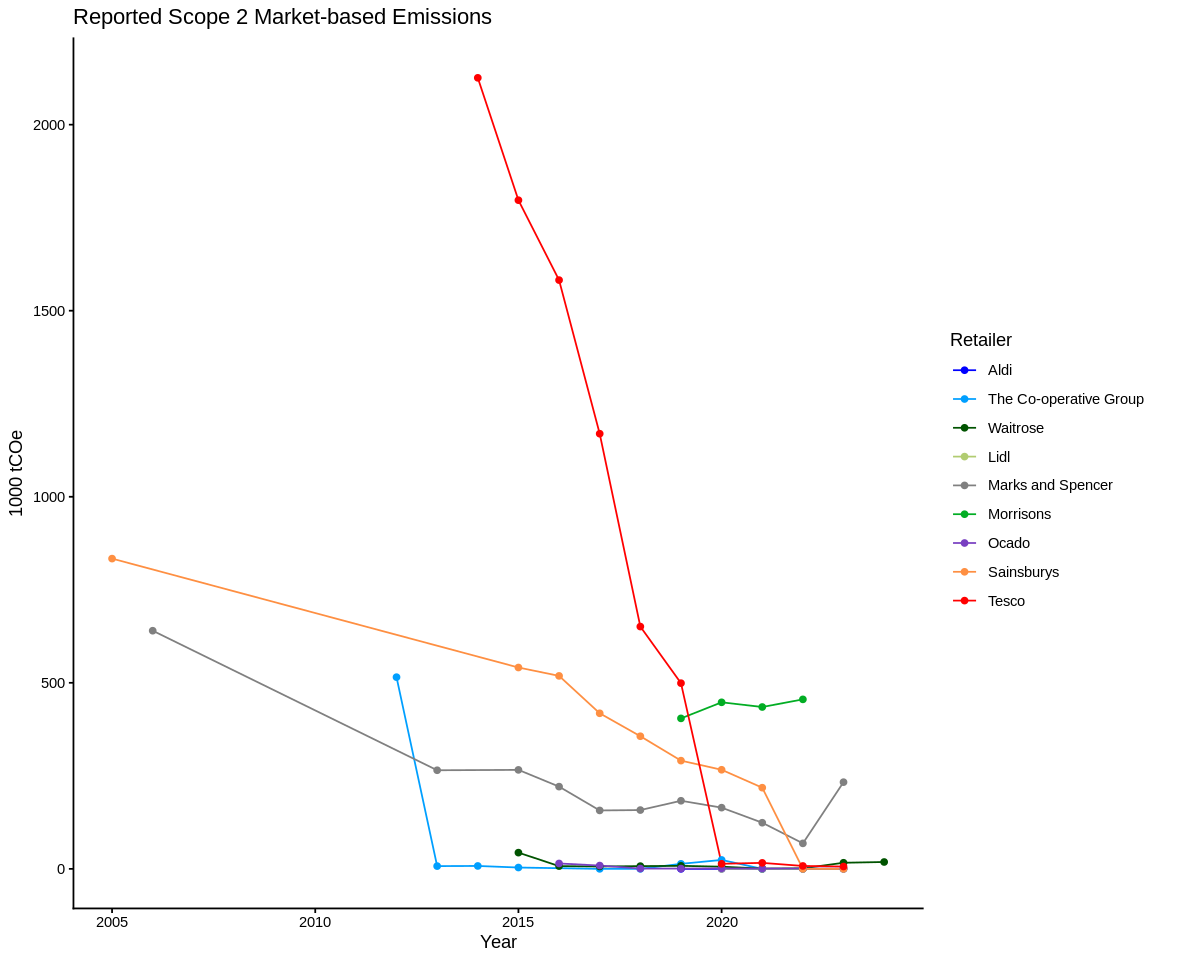

In [ ]:
# # Plot Absolute Scope 2 market-based emissions
ggplot(data.abs, aes(x = year, y = value/1000, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("Reported Scope 2 Market-based Emissions") +
  xlab("Year") +
  ylab("1000 tCOe") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()

* Market-based scope 2 metric are less common than location-based metrics.

* By 2023 most retailers only purchace electricity from renewable sources, howeer Morrisons and Marks and Spencer are exceptions.
* The COOP and Waitrose were early adopters.
* The 2023 increase in Marks and Spencer emissions arise from a change in policy and reporting method.

> "As outlined in the 2023 M&S Sustainability report we are no longer purchasing Renewable Energy Guarantees of Origin (REGOs) and we now calculate Scope 2 market-based emissions using supplier-specific emissions factors in line with the GHG protocol.” (Marks and Spencer Annual Report 2024, p. 57).

## Retailer Size

Larger retailer generate larger emissions but these can be offset by purchasing low or zero-carbon electricity, so size may or not be a controlling factor.

### Store Number

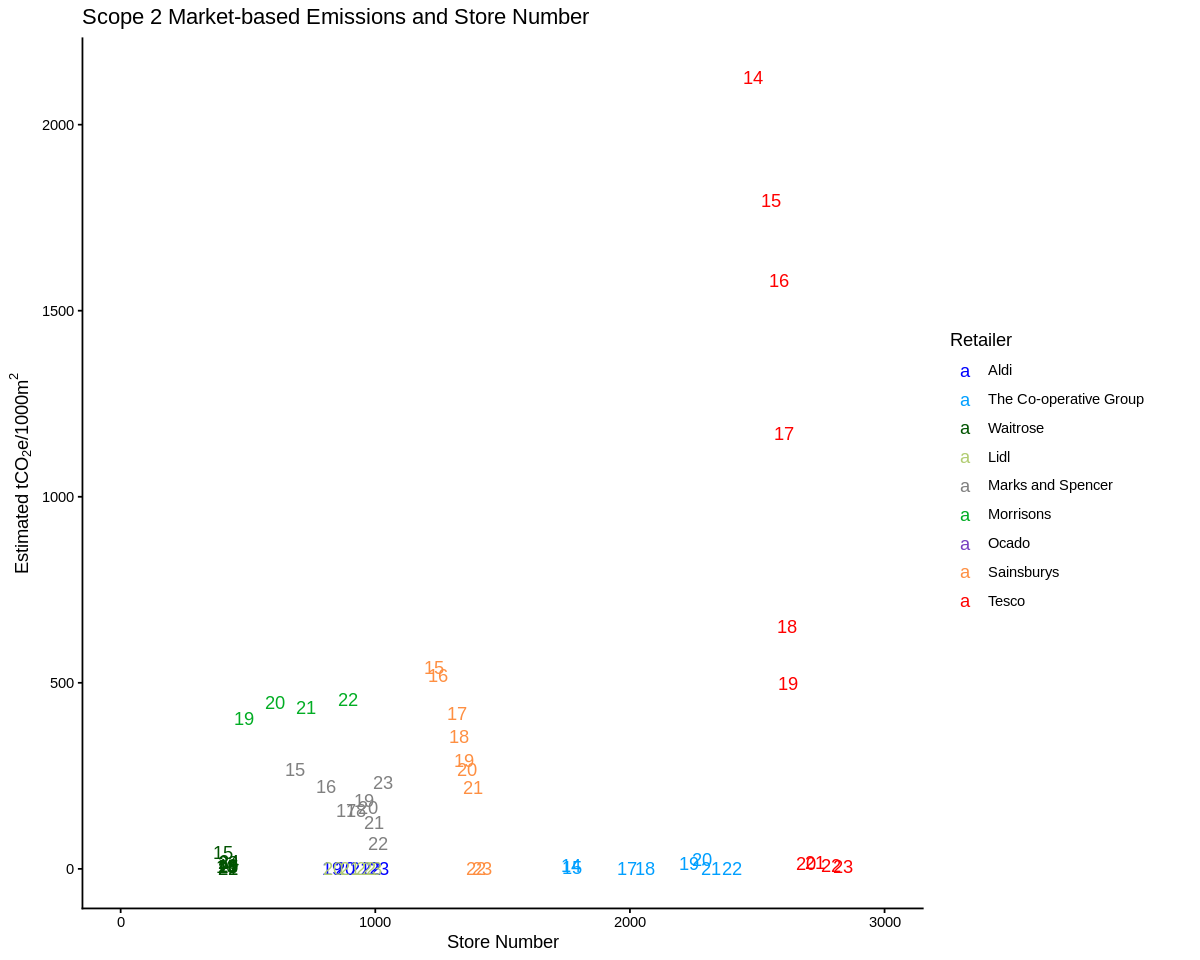

In [ ]:
ggplot(data.abs, aes(x = total_store, y = value/1000, colour = retailer_code, labels = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Scope 2 Market-based Emissions and Store Number") +
  xlab("Store Number") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 3000)) +
  theme_classic()

* No pattern is apparent.

[1] "Store Number"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.082|        -0.071| 160894.7|     0.534|   0.492|  1| -106.109| 218.218| 218.456| 155322613575|           6|    8|



|term             |  estimate|  std.error| statistic| p.value|
|:----------------|---------:|----------:|---------:|-------:|
|(Intercept)      | 165201.50| 113170.108|     1.460|   0.195|
|total_store_mean |    -54.78|     74.964|    -0.731|   0.492|

[1] ""

`geom_smooth()` using formula = 'y ~ x'


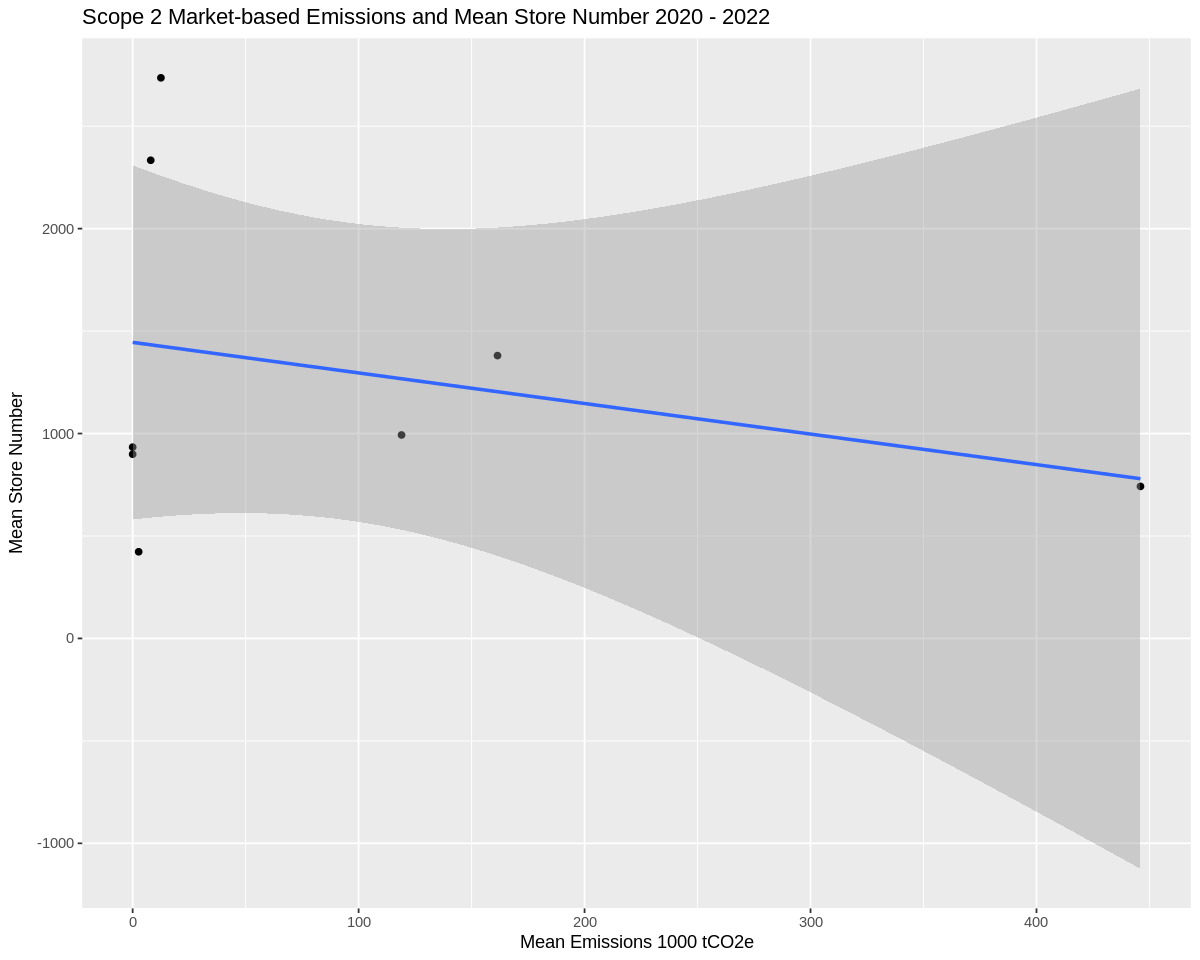

In [ ]:
# Scope 2 market ~ Store Number
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_store_mean)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Market-based Emissions and Mean Store Number 2020 - 2022") +
  xlab("Mean Emissions 1000 tCO2e") +
  ylab("Mean Store Number")

### Store Area

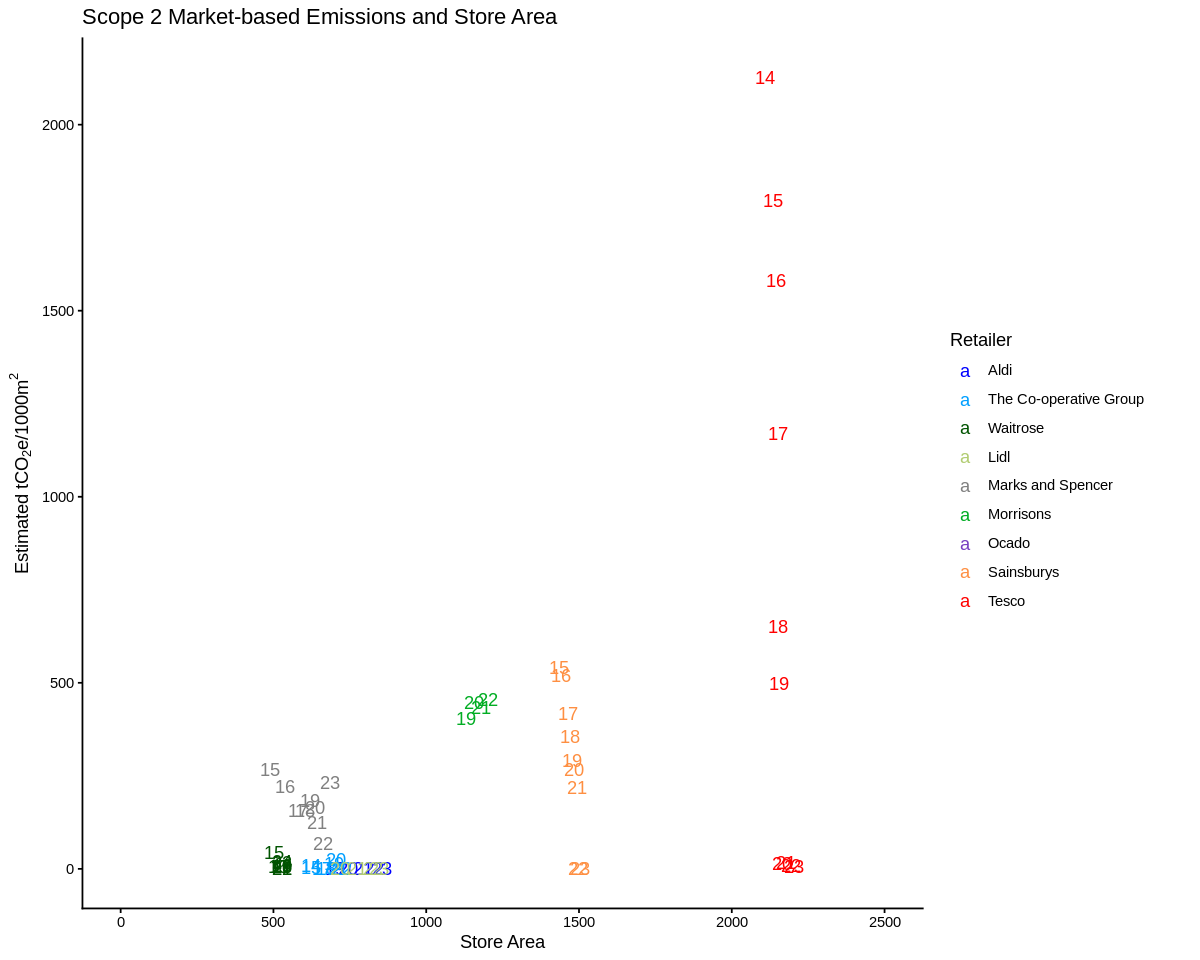

In [ ]:
  ggplot(data.abs, aes(x = total_area/1000, y = value/1000, colour = retailer_code, labels = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Scope 2 Market-based Emissions and Store Area") +
  xlab("Store Area") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 2500)) +
  theme_classic()

No pattern is apparent.

[1] "Store Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.027|        -0.135| 165588.2|     0.169|   0.695|  1| -106.339| 218.678| 218.916| 164516750905|           6|    8|



|term            |  estimate|  std.error| statistic| p.value|
|:---------------|---------:|----------:|---------:|-------:|
|(Intercept)     | 45908.051| 130230.487|     0.353|   0.737|
|total_area_mean |     0.046|      0.112|     0.411|   0.695|

[1] ""

`geom_smooth()` using formula = 'y ~ x'


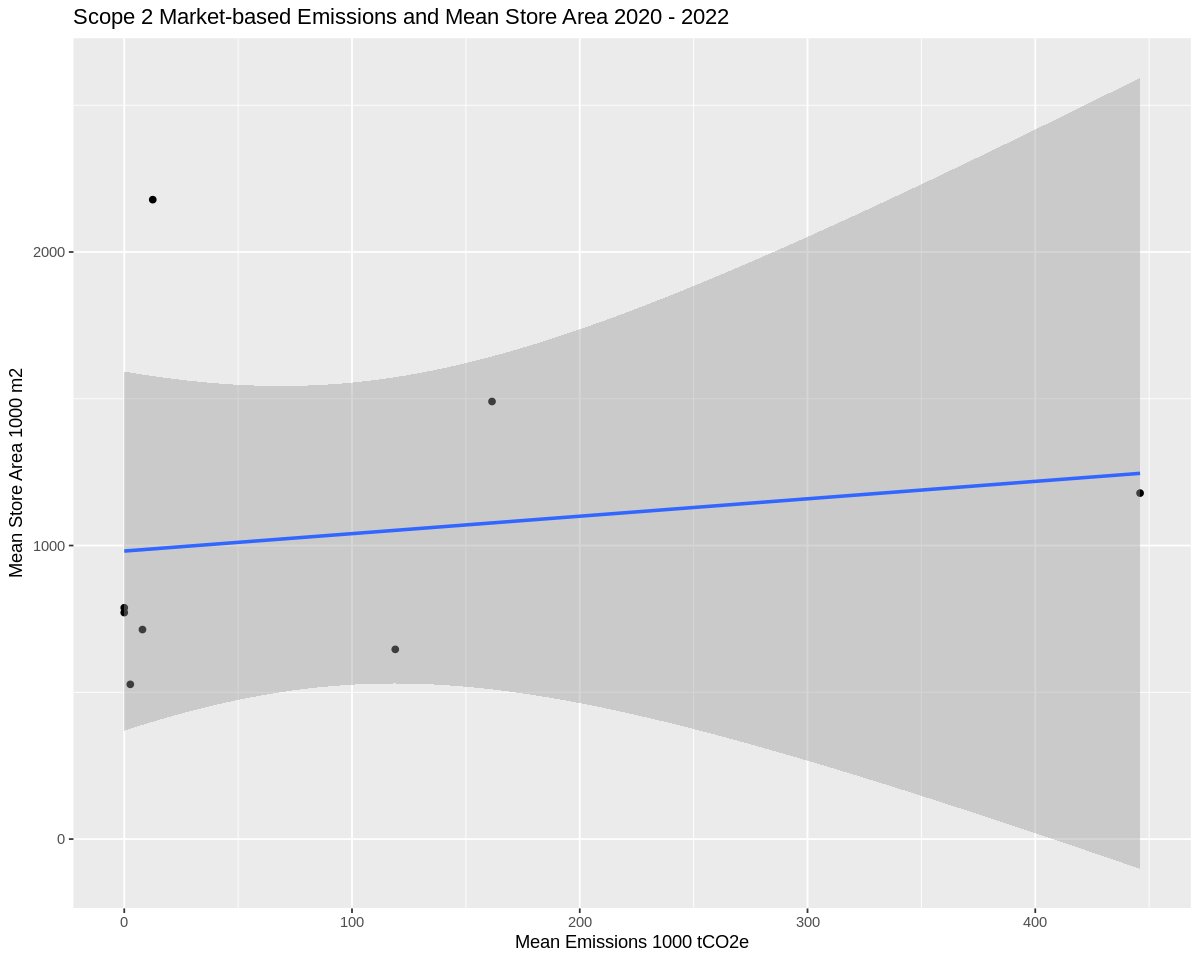

In [ ]:
# Scope 2 market ~ Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_area_mean, na.action=na.omit)
paste("Store Area")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_area_mean/1000)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Market-based Emissions and Mean Store Area 2020 - 2022") +
  xlab("Mean Emissions 1000 tCO2e") +
  ylab("Mean Store Area 1000 m2")

### Store Number and Area

In [ ]:
# Scope 2 market ~ Store Number + Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean + total_area_mean, na.action=na.omit)
paste("Store Number + Area")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

[1] "Store Number + Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|    AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|------:|-------:|------------:|-----------:|----:|
|     0.287|         0.002| 155277.3|     1.008|   0.429|  2| -105.095| 218.19| 218.508| 120555276208|           5|    8|



|term             |  estimate|  std.error| statistic| p.value|
|:----------------|---------:|----------:|---------:|-------:|
|(Intercept)      | 89154.619| 126251.217|     0.706|   0.512|
|total_store_mean |  -127.129|     94.149|    -1.350|   0.235|
|total_area_mean  |     0.164|      0.137|     1.201|   0.284|

[1] ""

### No Relationship

* All three models are insignificant, so there is no evidence of a relationship between Scope 2 market-based emissions and retailer size.

---
[Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

[Scope 1 and 2 Location](https://colab.research.google.com/drive/1oSahn6j_O1kPpGFbavaFJFIFtFoa8ngS?usp=sharing)

---